# Demo: explore one skill

Pick a **skill** and a **location** → see how many jobs require it, how many disclose a salary, the salary band split (Low/Mid/High), the skills that most often come with it (lift), and the job families hiring for it.

**How to run (≤ 2 minutes):** `pip install -r requirements.txt` → open the notebook → *Run All* → use the dropdowns.

**Required data:** `data/processed/jobs_clean.parquet` and `data/processed/skill_matrix.parquet` (download from Drive, or run `python scripts/run_pipeline.py skills`). Hashes must match `docs/MANIFEST.json`.

The notebook only shows aggregate numbers and **never** prints raw job-description text (ToS commitment, `docs/DECISIONS.md` 29/09).

In [1]:
import sys
from pathlib import Path

# Works whether the notebook is opened from the repo root or from notebooks/
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from src.viz.eda import FIGURES, group_label, load_data, save_figure, salary_tertiles, skill_share

# load_data() checks the SHA-256 of jobs_clean + skill_matrix against docs/MANIFEST.json and stops on mismatch
jobs, skills = load_data()
print(f"{len(jobs)} jobs, {skills.shape[1]} skills — hashes match docs/MANIFEST.json")

import ipywidgets as widgets

labels, (low, high) = salary_tertiles(jobs)
jobs["salary_class"] = labels  # NaN for jobs without a salary
CITIES = {"All": None, "Ho Chi Minh City": "loc_hcm", "Hanoi": "loc_hn", "Da Nang": "loc_dn"}
share = skill_share(skills)
print(f"Salary bands (tertiles): Low < {low:.1f} ≤ Mid < {high:.1f} ≤ High (million VND / month)")

688 jobs, 100 skills — hashes match docs/MANIFEST.json
Salary bands (tertiles): Low < 32.2 ≤ Mid < 50.0 ≤ High (million VND / month)


python — All: 175/688 jobs (25.4%); with a disclosed salary: 49
Median salary: 38.7 million VND / month


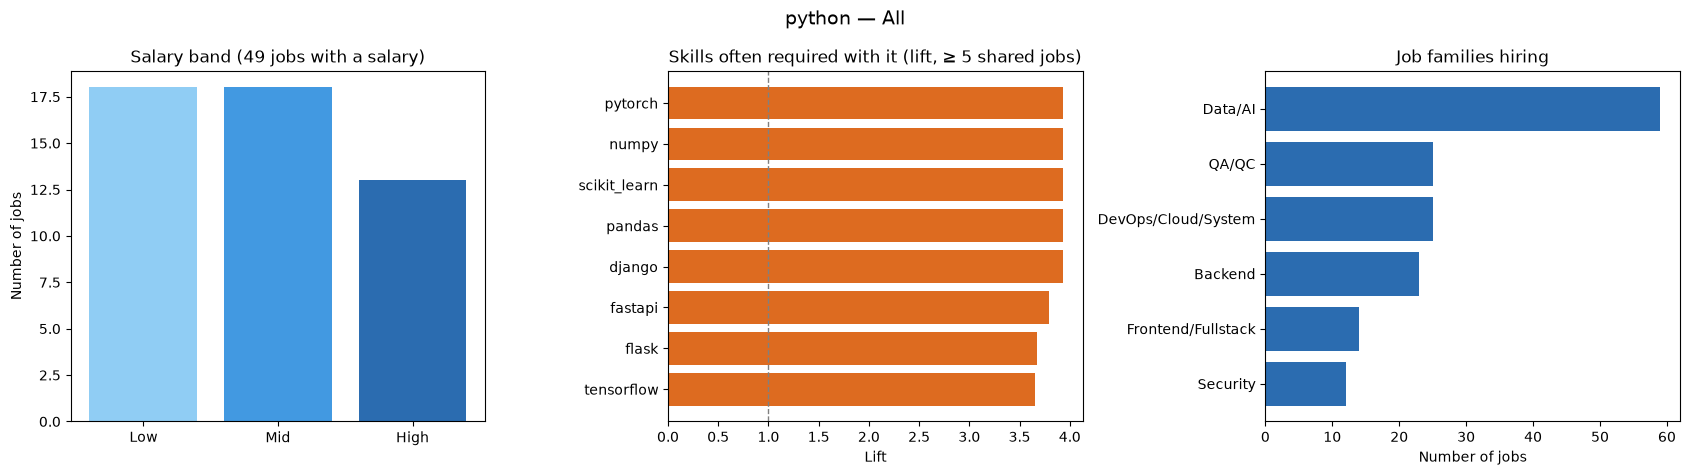

In [2]:
def explore(skill, city):
    scope = jobs.index if CITIES[city] is None else jobs.index[jobs[CITIES[city]] == 1]
    sk = skills.loc[scope]
    has_skill = sk[skill] == 1
    sub = jobs.loc[scope][has_skill]
    n, n_scope = len(sub), len(scope)
    if n == 0:
        print("No jobs."); return
    paid = sub[sub["has_salary"]]
    print(f"{skill} — {city}: {n}/{n_scope} jobs ({n / n_scope:.1%}); with a disclosed salary: {len(paid)}")
    if len(paid):
        print(f"Median salary: {paid['salary_mid'].median():.1f} million VND / month"
              + ("  ⚠️ small sample (< 10 jobs)" if len(paid) < 10 else ""))

    # co-occurring skills: lift = P(B|skill) / P(B), only skills appearing with `skill` in ≥ 5 jobs
    together = sk[has_skill].sum().drop(skill)
    lift = (together / n) / sk.mean().drop(skill)
    lift = lift[together >= 5].sort_values(ascending=False).head(8)

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
    dist = paid["salary_class"].value_counts().reindex(["Low", "Mid", "High"], fill_value=0)
    axes[0].bar(dist.index, dist.values, color=["#90cdf4", "#4299e1", "#2b6cb0"])
    axes[0].set_title(f"Salary band ({len(paid)} jobs with a salary)"); axes[0].set_ylabel("Number of jobs")
    axes[1].barh(lift.index[::-1], lift.values[::-1], color="#dd6b20")
    axes[1].axvline(1, color="grey", linestyle="--", linewidth=1)
    axes[1].set_title("Skills often required with it (lift, ≥ 5 shared jobs)"); axes[1].set_xlabel("Lift")
    groups = sub["expertise_group"].value_counts().head(6)
    axes[2].barh([group_label(g) for g in groups.index[::-1]], groups.values[::-1], color="#2b6cb0")
    axes[2].set_title("Job families hiring"); axes[2].set_xlabel("Number of jobs")
    fig.suptitle(f"{skill} — {city}", fontsize=14)
    fig.tight_layout()
    plt.show()


# Static example (also visible when viewing the notebook on GitHub, where widgets do not run)
explore("python", "All")

### Try it yourself

Change the skill / location in the dropdowns (requires running the notebook in Jupyter).

In [3]:
skill_options = [s for s in share.index if skills[s].sum() >= 10]  # enough jobs to be meaningful
widgets.interact(
    explore,
    skill=widgets.Dropdown(options=skill_options, value="python", description="Skill"),
    city=widgets.Dropdown(options=list(CITIES), value="All", description="Location"),
);

interactive(children=(Dropdown(description='Skill', index=8, options=('english', 'api', 'communication', 'cicd…

Numbers in the demo are aggregated by skill; individual postings and job-description text are never shown.